# Megadrought Analysis — Chilean Glacier Melt and Streamflow
### `megadrought_analysis.ipynb` | Millie Spencer | 2026

This notebook investigates how the Chilean Megadrought affected glacier melt
contributions to streamflow across Chile's latitudinal gradient. We compare
three drought period definitions against a 2000-2009 pre-drought baseline:

- **Period 1**: 2010-2019 (broad megadrought, Garreaud et al. 2020)
- **Period 2**: 2013-2019 (core intensification phase)
- **Period 3**: 2015-2019 (most severe phase)

For each period we ask:
1. How much did precipitation actually decline (empirical validation of period choice)?
2. Did glacier melt increase, decrease, or stay the same in absolute terms?
3. Did the relative importance of glacier melt (fraction of Q) increase?
4. Was the drought a conventional precipitation drought, a snow drought (warm + dry winter),
   or both?
5. How did temperature and PET change, and did these drive additional melt?

**Snow drought lens** (advisor suggestion): years where winter precipitation is
anomalously low or falls as rain rather than snow, reducing snowpack and making
glacier melt proportionally more important as a summer water source.


## 0. Imports, paths, and standalone setup

In [2]:
import os, pickle, calendar, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy import stats
import geopandas as gpd
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────
BASE_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
OUTPUT_ROOT  = f'{BASE_PATH}/Output'
CAMELS_FULL  = (f'{BASE_PATH}/Full_CAMELS_all_basins/CAMELS_CL_v202201')
RGI_PATH     = (f'{BASE_PATH}/files_chile_OGGM_climate_comparison/'
                f'RGI_BNA_Clusters.csv')
BOUNDS_PATH  = (f'{CAMELS_FULL}/camels_cl_boundaries/'
                f'camels_cl_boundaries.shp')
OUT_DIR      = f'{OUTPUT_ROOT}/all_chile_results_v2'
DROUGHT_DIR  = f'{OUT_DIR}/megadrought_analysis'
os.makedirs(DROUGHT_DIR, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
YEARS         = list(range(2000, 2020))
MONTHS        = list(range(1, 13))
YEAR_OFFSET   = 1
WATER_DENSITY = 1000
CLUSTERS      = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']
DATASETS      = {'CR2MET': 'TC', 'ERA5': 'ERA5', 'CRU': 'CRU'}
DS_COLORS     = {'CR2MET': '#1f77b4', 'ERA5': '#ff7f0e', 'CRU': '#2ca02c'}
REGION_LABELS = {
    'OT3': 'Altiplano',     'DA1': 'Dry Andes N',
    'DA2': 'Dry Andes C',   'DA3': 'Dry Andes S',
    'WA1': 'Wet Andes N',   'WA2': 'Wet Andes C',
    'WA3': 'N Patagonia',   'WA4': 'S Patagonia',
    'WA5': 'Patagonia',     'WA6': 'Tierra del Fuego',
}
BASELINE     = list(range(2000, 2010))
DROUGHT_DEFS = {
    'Baseline (2000-2009)':  list(range(2000, 2010)),
    'Drought 1 (2010-2019)': list(range(2010, 2020)),
    'Drought 2 (2013-2019)': list(range(2013, 2020)),
    'Drought 3 (2015-2019)': list(range(2015, 2020)),
}
DROUGHT_COLORS = {
    'Baseline (2000-2009)':  '#2ecc71',
    'Drought 1 (2010-2019)': '#f39c12',
    'Drought 2 (2013-2019)': '#e67e22',
    'Drought 3 (2015-2019)': '#c0392b',
}
SUMMER = [12, 1, 2]
WINTER = [6, 7, 8]

def nc_path(dataset_name, cluster):
    tag = DATASETS[dataset_name]
    return (f'{OUTPUT_ROOT}/{dataset_name}/{cluster}/'
            f'run_output_2000_2019_hydro_{tag}_{cluster}.nc')

# ── Load RESULTS ───────────────────────────────────────────────────────────
print('Loading RESULTS from pickle...')
with open(f'{OUT_DIR}/RESULTS.pkl', 'rb') as f:
    RESULTS = pickle.load(f)
print(f'  RESULTS loaded: {len(RESULTS["CR2MET"])} gauges')

# ── Rebuild GAUGE_INFO_FRAC from saved CSVs ────────────────────────────────
# Use the gauge completeness CSV saved by the main notebook
# instead of re-running the slow daily completeness filter
print('Loading spatial join and completeness data...')

nested_csv = pd.read_csv(f'{OUT_DIR}/spatial_join_nested.csv',
                         dtype={'gauge_id': str})
comp_csv   = pd.read_csv(f'{OUT_DIR}/gauge_completeness_assessment.csv',
                         dtype={'gauge_id': str})

# Build GAUGE_INFO from nested CSV
GAUGE_INFO = {}
for gauge_id, grp in nested_csv.groupby('gauge_id'):
    GAUGE_INFO[gauge_id] = {
        'gauge_name':       grp['gauge_name'].iloc[0],
        'rgi_ids':          grp['RGIId'].tolist(),
        'n_glaciers':       len(grp),
        'glacier_area_km2': grp['Area'].sum(),
        'basin_area_km2':   grp['area_km2'].iloc[0],
        'clusters':         sorted(grp['Cluster'].unique().tolist()),
        'cen_lat':          grp['CenLat'].mean(),
        'cen_lon':          grp['CenLon'].mean(),
    }

# Load q_wide for streamflow data (monthly, much faster than daily)
q_wide = pd.read_csv(f'{CAMELS_FULL}/q_m3s_mon.csv', parse_dates=['date'])
q_wide = q_wide[(q_wide['year'] >= 2000) &
                (q_wide['year'] <= 2019)].reset_index(drop=True)

# Build GAUGE_INFO_FRAC using completeness CSV
# The main notebook saved which gauges pass and their complete_years
gauges_in_results = set(RESULTS['CR2MET'].keys())
GAUGE_INFO_FRAC   = {}

for _, row in comp_csv[comp_csv['passes'] == True].iterrows():
    gauge_id = str(row['gauge_id'])
    if gauge_id not in gauges_in_results:
        continue
    if gauge_id not in GAUGE_INFO:
        continue
    info = dict(GAUGE_INFO[gauge_id])
    # Reconstruct complete_years from RESULTS if available
    res = RESULTS['CR2MET'].get(gauge_id)
    if res is not None and 'complete_years' in res:
        info['complete_years'] = res['complete_years']
    else:
        # Fall back: use all years with valid Q
        info['complete_years'] = YEARS
    GAUGE_INFO_FRAC[gauge_id] = info

# Remove the 6 high-frac excluded gauges
excluded = pd.read_csv(f'{OUT_DIR}/excluded_high_frac_gauges.csv',
                       dtype={'gauge_id': str})
for gauge_id in excluded['gauge_id'].tolist():
    GAUGE_INFO_FRAC.pop(gauge_id, None)

print(f'  GAUGE_INFO:      {len(GAUGE_INFO)} gauges')
print(f'  GAUGE_INFO_FRAC: {len(GAUGE_INFO_FRAC)} gauges (after exclusions)')
print()
print('Cell 0 complete')

Loading RESULTS from pickle...
  RESULTS loaded: 143 gauges
Loading spatial join and completeness data...
  GAUGE_INFO:      266 gauges
  GAUGE_INFO_FRAC: 137 gauges (after exclusions)

Cell 0 complete


## I. Load CAMELS-CL basin-average climate data

We load basin-average monthly precipitation, temperature, tmax, tmin, and PET
from CAMELS-CL (CR2MET). These are the climate variables we will use to:
1. Empirically validate our drought period definitions
2. Diagnose whether drought years were precipitation-driven, temperature-driven,
   or snow-drought (warm + dry winter) events
3. Decompose the drivers of increased glacier fraction during drought


In [3]:
print('Loading CAMELS-CL climate...')

def load_camels_mon(fname, value_name, year_range=(2000,2019)):
    df = pd.read_csv(f'{CAMELS_FULL}/{fname}')
    df = df[(df['year'] >= year_range[0]) &
            (df['year'] <= year_range[1])].copy()
    gauge_cols = [c for c in df.columns
                  if c not in ['date','year','month','day']]
    return df[['year','month'] + gauge_cols]

precip_df = load_camels_mon('precip_cr2met_mm_mon.csv',  'precip')
tmean_df  = load_camels_mon('tmean_cr2met_C_mon.csv',    'tmean')
tmax_df   = load_camels_mon('tmax_cr2met_C_mon.csv',     'tmax')
tmin_df   = load_camels_mon('tmin_cr2met_C_mon.csv',     'tmin')
pet_df    = load_camels_mon('pet_hargreaves_mm_mon.csv', 'pet')

print(f'Precip:  {precip_df.shape}')
print(f'Tmean:   {tmean_df.shape}')
print(f'PET:     {pet_df.shape}')
print('CAMELS-CL climate loaded')


Loading CAMELS-CL climate...
Precip:  (240, 518)
Tmean:   (240, 519)
PET:     (240, 518)
CAMELS-CL climate loaded


## II. Empirical validation of drought period definitions

Before comparing glacier melt across periods, we confirm that our three drought
period definitions correspond to real precipitation deficits in the CAMELS-CL
data. We compute annual and seasonal precipitation anomalies relative to the
2000-2009 baseline for each cluster, using the basin-average CR2MET data.

This addresses the key question: do 2010-2019, 2013-2019, and 2015-2019
represent progressively more severe drought conditions, or are the differences
minor?


Computing annual climate aggregations...
  ann_precip: (20, 516)
  ann_tmean:  (20, 516)
Annual aggregations done — computing cluster means...
  WA5: no gauges found — skipping
Climate DataFrame built: (180, 7)

Annual precipitation anomaly vs 2000-2009 baseline (%) by period:
Cluster  Drought 1 (2010-2019)   Drought 2 (2013-2019)   Drought 3 (2015-2019) 
--------------------------------------------------------------------------------
OT3     -1.1%                    -5.3%                    -1.5%                  
DA1     -3.6%                    +1.2%                    +15.8%                  
DA2     -40.0%                    -37.5%                    -36.3%                  
DA3     -29.6%                    -28.6%                    -28.0%                  
WA1     -16.6%                    -15.9%                    -17.2%                  
WA2     -5.0%                    -5.5%                    -7.5%                  
WA3     +9.5%                    +9.4%                    +

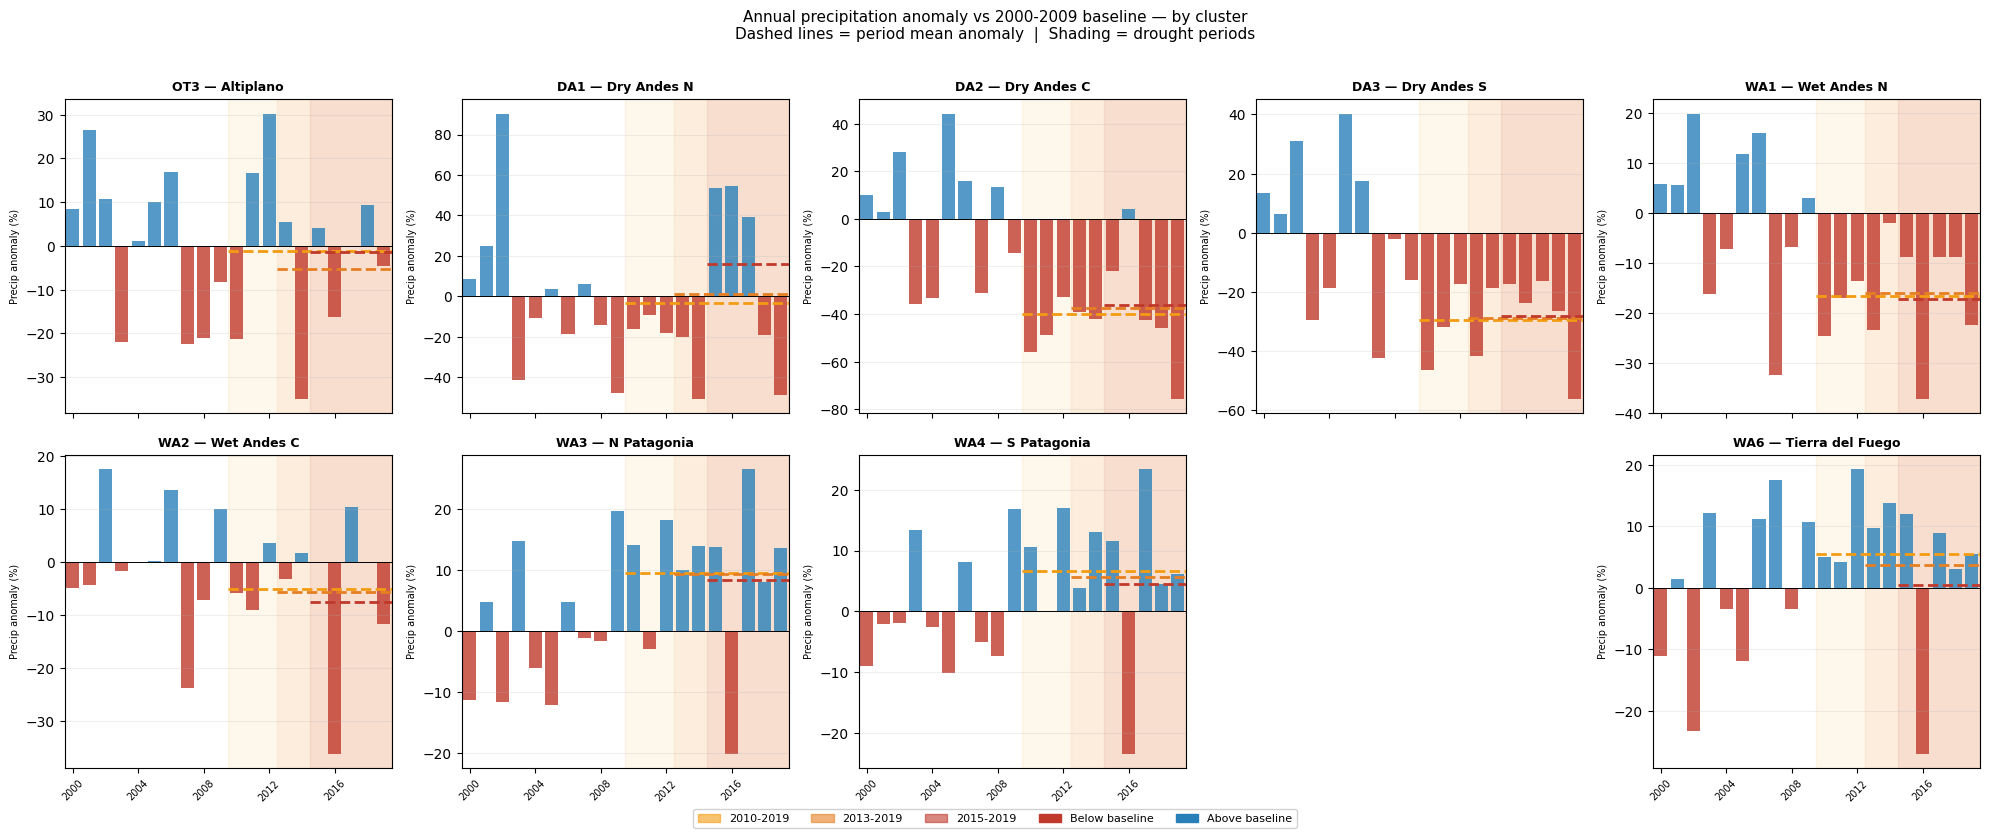

In [5]:
# ── Cell 2: Empirical validation of drought period definitions ─────────────
#
# Computes annual and seasonal precipitation anomalies relative to the
# 2000-2009 baseline for each cluster, using basin-average CR2MET data.
# Validates that our three drought period definitions correspond to real
# precipitation deficits in the data.

NON_GAUGE = ['date', 'year', 'month', 'day']

cluster_gauges = {cl: [gid for gid, info in GAUGE_INFO_FRAC.items()
                        if info['clusters'][0] == cl]
                  for cl in CLUSTERS}

print('Computing annual climate aggregations...')

def season_agg(df, months, agg='sum'):
    gauge_cols = [c for c in df.columns if c not in NON_GAUGE]
    sub = df[df['month'].isin(months)][['year'] + gauge_cols]
    if agg == 'sum':
        return sub.groupby('year')[gauge_cols].sum(numeric_only=True)
    return sub.groupby('year')[gauge_cols].mean(numeric_only=True)

ann_precip = season_agg(precip_df, list(range(1,13)), 'sum')
sum_precip = season_agg(precip_df, SUMMER,            'sum')
win_precip = season_agg(precip_df, WINTER,            'sum')
ann_tmean  = season_agg(tmean_df,  list(range(1,13)), 'mean')
ann_pet    = season_agg(pet_df,    list(range(1,13)), 'sum')

print(f'  ann_precip: {ann_precip.shape}')
print(f'  ann_tmean:  {ann_tmean.shape}')
print('Annual aggregations done — computing cluster means...')

# ── Cluster-mean timeseries ────────────────────────────────────────────────
clim_records = []
for cl in CLUSTERS:
    gauges = [g for g in cluster_gauges[cl] if g in ann_precip.columns]
    if not gauges:
        print(f'  {cl}: no gauges found — skipping')
        continue
    for year in YEARS:
        def get_val(df_wide, yr):
            if yr not in df_wide.index:
                return np.nan
            cols = [g for g in gauges if g in df_wide.columns]
            return df_wide.loc[yr, cols].mean() if cols else np.nan

        clim_records.append({
            'cluster':    cl,
            'year':       year,
            'precip_ann': get_val(ann_precip, year),
            'precip_sum': get_val(sum_precip, year),
            'precip_win': get_val(win_precip, year),
            'tmean_ann':  get_val(ann_tmean,  year),
            'pet_ann':    get_val(ann_pet,    year),
        })

df_clim = pd.DataFrame(clim_records)
print(f'Climate DataFrame built: {df_clim.shape}')

# ── Compute anomalies vs 2000-2009 baseline ───────────────────────────────
baseline_means = (df_clim[df_clim['year'].isin(BASELINE)]
                  .groupby('cluster')[
                      ['precip_ann','precip_sum','precip_win',
                       'tmean_ann','pet_ann']].mean()
                  .rename(columns=lambda c: c + '_base'))

df_clim = df_clim.merge(baseline_means, on='cluster', how='left')
df_clim['precip_ann_anom_pct'] = ((df_clim['precip_ann'] -
                                    df_clim['precip_ann_base']) /
                                   df_clim['precip_ann_base'] * 100)
df_clim['precip_win_anom_pct'] = ((df_clim['precip_win'] -
                                    df_clim['precip_win_base']) /
                                   df_clim['precip_win_base'] * 100)
df_clim['tmean_anom']          = (df_clim['tmean_ann'] -
                                   df_clim['tmean_ann_base'])
df_clim['pet_anom_pct']        = ((df_clim['pet_ann'] -
                                    df_clim['pet_ann_base']) /
                                   df_clim['pet_ann_base'] * 100)

# ── Period means table ────────────────────────────────────────────────────
print('\nAnnual precipitation anomaly vs 2000-2009 baseline (%) by period:')
print(f'{"Cluster":6s}', end='')
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    print(f'  {period_label:22s}', end='')
print()
print('-' * 80)

for cl in CLUSTERS:
    cl_df = df_clim[df_clim['cluster'] == cl]
    if len(cl_df) == 0:
        continue
    print(f'{cl:6s}', end='')
    for period_label, years in list(DROUGHT_DEFS.items())[1:]:
        anom = cl_df[cl_df['year'].isin(years)]['precip_ann_anom_pct'].mean()
        print(f'  {anom:+.1f}%{" "*18}', end='')
    print()

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
axes_flat = axes.flatten()

for ax, cl in zip(axes_flat, CLUSTERS):
    cl_df = df_clim[df_clim['cluster'] == cl].set_index('year')
    if len(cl_df) == 0:
        ax.set_visible(False)
        continue

    colors = ['#c0392b' if v < 0 else '#2980b9'
              for v in cl_df['precip_ann_anom_pct']]
    ax.bar(cl_df.index, cl_df['precip_ann_anom_pct'],
           color=colors, alpha=0.8, edgecolor='none')
    ax.axhline(0, color='k', lw=0.7)

    # Shade drought periods
    for period_label, years in list(DROUGHT_DEFS.items())[1:]:
        ax.axvspan(min(years)-0.5, max(years)+0.5,
                   color=DROUGHT_COLORS[period_label],
                   alpha=0.08, zorder=0)

    # Period mean anomaly lines
    for period_label, years in list(DROUGHT_DEFS.items())[1:]:
        mean_anom = cl_df.loc[
            cl_df.index.isin(years), 'precip_ann_anom_pct'].mean()
        if not np.isnan(mean_anom):
            ax.hlines(mean_anom, min(years)-0.5, max(years)+0.5,
                      color=DROUGHT_COLORS[period_label],
                      lw=2, ls='--', zorder=5)

    ax.set_title(f'{cl} — {REGION_LABELS[cl]}', fontsize=9,
                 fontweight='bold')
    ax.set_ylabel('Precip anomaly (%)', fontsize=7)
    ax.set_xlim(1999.5, 2019.5)
    ax.set_xticks(range(2000, 2020, 4))
    ax.tick_params(labelsize=7, axis='x', rotation=45)
    ax.grid(True, alpha=0.2, axis='y')

fig.legend(
    handles=[
        Patch(color=DROUGHT_COLORS['Drought 1 (2010-2019)'], alpha=0.6,
              label='2010-2019'),
        Patch(color=DROUGHT_COLORS['Drought 2 (2013-2019)'], alpha=0.6,
              label='2013-2019'),
        Patch(color=DROUGHT_COLORS['Drought 3 (2015-2019)'], alpha=0.6,
              label='2015-2019'),
        Patch(color='#c0392b', label='Below baseline'),
        Patch(color='#2980b9', label='Above baseline'),
    ],
    loc='lower center', ncol=5, fontsize=8,
    bbox_to_anchor=(0.5, -0.02), framealpha=0.9)

fig.suptitle(
    'Annual precipitation anomaly vs 2000-2009 baseline — by cluster\n'
    'Dashed lines = period mean anomaly  |  Shading = drought periods',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/precip_anomaly_by_cluster.png',
            dpi=150, bbox_inches='tight')
plt.show()

## III. Snow drought diagnosis

A snow drought occurs when winter precipitation is anomalously low OR falls
as rain rather than snow due to warm temperatures, reducing snowpack and
amplifying the importance of glacier melt in summer.

We distinguish two types:
- **Dry snow drought**: below-normal winter precipitation (less snow input)
- **Warm snow drought**: normal or near-normal precipitation but above-normal
  winter temperatures causing precipitation to fall as rain rather than snow

We diagnose this by comparing winter precipitation anomalies against winter
temperature anomalies across the three drought periods.


Snow drought diagnosis by cluster and period:

Cluster Period                    Win precip anom%  Ann temp anom°C  Drought type
--------------------------------------------------------------------------------
OT3    Drought 1 (2010-2019)     -14.4%           +0.22°C          Mild / no snow drought
OT3    Drought 2 (2013-2019)     +8.0%           +0.22°C          Mild / no snow drought
OT3    Drought 3 (2015-2019)     -1.9%           +0.32°C          Warm snow drought

DA1    Drought 1 (2010-2019)     -25.6%           +0.15°C          Dry snow drought
DA1    Drought 2 (2013-2019)     -20.3%           +0.28°C          Dry snow drought
DA1    Drought 3 (2015-2019)     -1.8%           +0.39°C          Warm snow drought

DA2    Drought 1 (2010-2019)     -54.8%           +0.07°C          Dry snow drought
DA2    Drought 2 (2013-2019)     -55.8%           +0.17°C          Dry snow drought
DA2    Drought 3 (2015-2019)     -54.1%           +0.25°C          Dry snow drought

DA3    Drought 1 (20

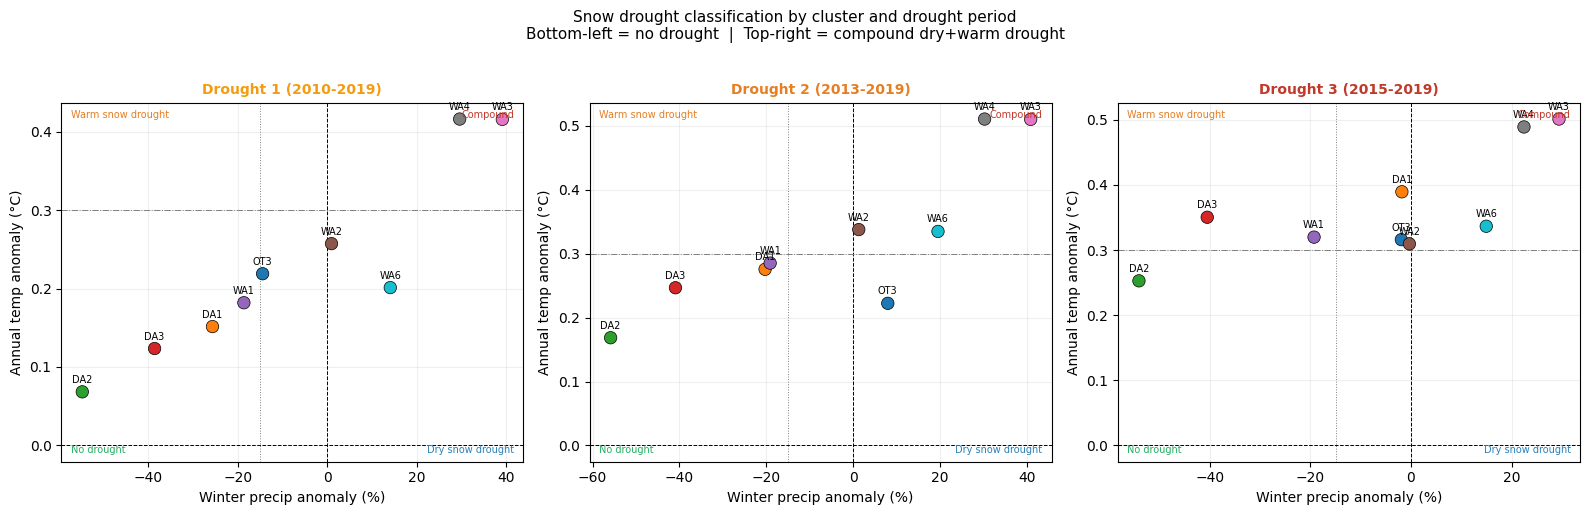

In [7]:
# ── Cell 3: Snow drought diagnosis ────────────────────────────────────────

print('Snow drought diagnosis by cluster and period:')
print()
print(f'{"Cluster":6s} {"Period":25s} {"Win precip anom%":17s} '
      f'{"Ann temp anom°C":16s} {"Drought type"}')
print('-' * 80)

snow_drought_records = []
for cl in CLUSTERS:
    cl_df = df_clim[df_clim['cluster'] == cl]
    if len(cl_df) == 0:
        continue
    for period_label, years in list(DROUGHT_DEFS.items())[1:]:
        period_df    = cl_df[cl_df['year'].isin(years)]
        win_anom_pct = period_df['precip_win_anom_pct'].mean()
        temp_anom    = period_df['tmean_anom'].mean()

        if win_anom_pct < -15 and temp_anom > 0.3:
            dtype = 'Compound (dry + warm)'
        elif win_anom_pct < -15:
            dtype = 'Dry snow drought'
        elif temp_anom > 0.3:
            dtype = 'Warm snow drought'
        else:
            dtype = 'Mild / no snow drought'

        print(f'{cl:6s} {period_label:25s} {win_anom_pct:+.1f}%'
              f'{"":10s} {temp_anom:+.2f}°C{"":9s} {dtype}')

        snow_drought_records.append({
            'cluster':       cl,
            'period':        period_label,
            'win_prec_anom': win_anom_pct,
            'temp_anom':     temp_anom,
            'dtype':         dtype,
        })
    print()

df_snow_drought = pd.DataFrame(snow_drought_records)

# ── Figure ────────────────────────────────────────────────────────────────
drought_period_labels = list(DROUGHT_DEFS.keys())[1:]   # just the 3 drought periods
fig, axes = plt.subplots(1, 3, figsize=(16, 5))          # 3 panels, one per period

for ax, period_label in zip(axes, drought_period_labels):
    period_df = df_snow_drought[df_snow_drought['period'] == period_label]

    sc = ax.scatter(
        period_df['win_prec_anom'],
        period_df['temp_anom'],
        c=[list(CLUSTERS).index(cl) for cl in period_df['cluster']],
        cmap='tab10', vmin=0, vmax=9,
        s=80, edgecolors='k', lw=0.5, zorder=3)

    for _, row in period_df.iterrows():
        ax.annotate(row['cluster'],
                    (row['win_prec_anom'], row['temp_anom']),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

    ax.axvline(0,   color='k',    lw=0.7, ls='--')
    ax.axhline(0,   color='k',    lw=0.7, ls='--')
    ax.axvline(-15, color='grey', lw=0.7, ls=':')
    ax.axhline(0.3, color='grey', lw=0.7, ls='-.')

    ax.text(0.02, 0.98, 'Warm snow drought',
            transform=ax.transAxes, fontsize=7, va='top', color='#e67e22')
    ax.text(0.02, 0.02, 'No drought',
            transform=ax.transAxes, fontsize=7, va='bottom', color='#27ae60')
    ax.text(0.98, 0.98, 'Compound',
            transform=ax.transAxes, fontsize=7, va='top', ha='right',
            color='#c0392b')
    ax.text(0.98, 0.02, 'Dry snow drought',
            transform=ax.transAxes, fontsize=7, va='bottom', ha='right',
            color='#2980b9')

    ax.set_xlabel('Winter precip anomaly (%)', fontsize=10)
    ax.set_ylabel('Annual temp anomaly (°C)', fontsize=10)
    ax.set_title(period_label, fontsize=10, fontweight='bold',
                 color=DROUGHT_COLORS[period_label])
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'Snow drought classification by cluster and drought period\n'
    'Bottom-left = no drought  |  Top-right = compound dry+warm drought',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/snow_drought_classification.png',
            dpi=150, bbox_inches='tight')
plt.show()

## IV. Glacier melt during drought — absolute and relative changes

For each basin and drought period, we compute:
1. Mean annual glacier runoff (km³/yr) — did melt increase or decrease?
2. Mean annual observed Q (km³/yr) — how much did streamflow decline?
3. Mean glacier fraction (%) — did relative importance increase?
4. Drought amplification factor = drought fraction / baseline fraction

We do this for all three datasets and report the multi-dataset mean.


In [8]:
# ── Compute period means per basin ────────────────────────────────────────
print('Computing period means for all basins...')

period_records = []

for gauge_id, info in GAUGE_INFO_FRAC.items():
    cy = info['complete_years']

    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        res = RESULTS[ds_name].get(gauge_id)
        if res is None:
            continue
        m = res['monthly']

        for period_label, years in DROUGHT_DEFS.items():
            valid_years = [y for y in years if y in cy]
            if len(valid_years) < 2:
                continue

            period_m = m[m['year'].isin(valid_years)]
            ann = period_m.groupby('year').agg(
                glac_m3=('glacier_runoff_m3', 'sum'),
                q_m3   =('q_m3_mon',          'sum'),
                melt_m3=('melt_on_glacier_m3', 'sum'),
                liq_m3 =('liq_prcp_on_glacier_m3', 'sum'),
            )
            ann = ann[ann['q_m3'] > 0]
            if len(ann) == 0:
                continue

            period_records.append({
                'gauge_id':        gauge_id,
                'gauge_name':      info['gauge_name'][:35],
                'lat':             info['cen_lat'],
                'cluster':         info['clusters'][0],
                'glacier_area_km2': info['glacier_area_km2'],
                'basin_area_km2':  info['basin_area_km2'],
                'dataset':         ds_name,
                'period':          period_label,
                'n_years':         len(ann),
                'glac_km3yr':      ann['glac_m3'].mean() / 1e9,
                'q_km3yr':         ann['q_m3'].mean()    / 1e9,
                'melt_km3yr':      ann['melt_m3'].mean() / 1e9,
                'liq_km3yr':       ann['liq_m3'].mean()  / 1e9,
                'frac_mean':       (ann['glac_m3'] / ann['q_m3']).mean(),
            })

df_periods = pd.DataFrame(period_records)
print(f'Period records: {len(df_periods):,}')

# ── Compute amplification factor: drought frac / baseline frac ────────────
baseline_fracs = (df_periods[df_periods['period'] == 'Baseline (2000-2009)']
                  [['gauge_id','dataset','frac_mean','glac_km3yr','q_km3yr']]
                  .rename(columns={'frac_mean':   'frac_base',
                                   'glac_km3yr':  'glac_base',
                                   'q_km3yr':     'q_base'}))

df_periods = df_periods.merge(baseline_fracs,
                               on=['gauge_id','dataset'], how='left')
df_periods['amp_factor']  = (df_periods['frac_mean'] /
                              df_periods['frac_base'])
df_periods['glac_chg_pct'] = ((df_periods['glac_km3yr'] -
                                df_periods['glac_base']) /
                               df_periods['glac_base'] * 100)
df_periods['q_chg_pct']    = ((df_periods['q_km3yr'] -
                                df_periods['q_base']) /
                               df_periods['q_base'] * 100)

# ── Summary table by cluster and period ───────────────────────────────────
print()
print('Multi-dataset mean: drought amplification factor by cluster')
print('(glacier fraction during drought / glacier fraction during baseline)')
print()
print(f'{"Cluster":6s}', end='')
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    print(f'  {period_label:22s}', end='')
print()
print('-' * 85)

for cl in CLUSTERS:
    print(f'{cl:6s}', end='')
    for period_label in list(DROUGHT_DEFS.keys())[1:]:
        sub = df_periods[
            (df_periods['cluster'] == cl) &
            (df_periods['period']  == period_label) &
            (df_periods['amp_factor'].notna()) &
            (df_periods['amp_factor'] < 10)   # exclude implausible
        ]
        if len(sub) == 0:
            print(f'  {"n/a":22s}', end='')
        else:
            amp = sub['amp_factor'].median()
            print(f'  {amp:.2f}x{" "*19}', end='')
    print()

# ── Also print Q and glacier melt changes ─────────────────────────────────
print()
print('Q change % vs baseline (multi-dataset median):')
print(f'{"Cluster":6s}', end='')
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    print(f'  {period_label:22s}', end='')
print()
print('-' * 85)
for cl in CLUSTERS:
    print(f'{cl:6s}', end='')
    for period_label in list(DROUGHT_DEFS.keys())[1:]:
        sub = df_periods[
            (df_periods['cluster'] == cl) &
            (df_periods['period']  == period_label)]
        if len(sub) == 0:
            print(f'  {"n/a":22s}', end='')
        else:
            chg = sub['q_chg_pct'].median()
            print(f'  {chg:+.1f}%{" "*18}', end='')
    print()

print()
print('Glacier melt change % vs baseline (multi-dataset median):')
print(f'{"Cluster":6s}', end='')
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    print(f'  {period_label:22s}', end='')
print()
print('-' * 85)
for cl in CLUSTERS:
    print(f'{cl:6s}', end='')
    for period_label in list(DROUGHT_DEFS.keys())[1:]:
        sub = df_periods[
            (df_periods['cluster'] == cl) &
            (df_periods['period']  == period_label)]
        if len(sub) == 0:
            print(f'  {"n/a":22s}', end='')
        else:
            chg = sub['glac_chg_pct'].median()
            print(f'  {chg:+.1f}%{" "*18}', end='')
    print()


Computing period means for all basins...
Period records: 1,578

Multi-dataset mean: drought amplification factor by cluster
(glacier fraction during drought / glacier fraction during baseline)

Cluster  Drought 1 (2010-2019)   Drought 2 (2013-2019)   Drought 3 (2015-2019) 
-------------------------------------------------------------------------------------
OT3     1.84x                     1.44x                     1.55x                   
DA1     2.67x                     2.34x                     1.50x                   
DA2     2.82x                     2.86x                     3.70x                   
DA3     1.90x                     1.95x                     2.14x                   
WA1     1.58x                     1.66x                     1.84x                   
WA2     1.22x                     1.28x                     1.39x                   
WA3     1.07x                     1.12x                     1.17x                   
WA4     1.00x                     1.04x      

## V. Decomposing the drought amplification signal

The increase in glacier fraction during drought can be driven by:
1. **Q decline** — streamflow falls while glacier melt stays the same
2. **Melt increase** — glacier melt increases due to higher temperatures
3. **Both** — Q declines AND melt increases

We quantify the relative contribution of each mechanism following the
approach used in the WA1 analysis, extended to all clusters and all
three drought periods.


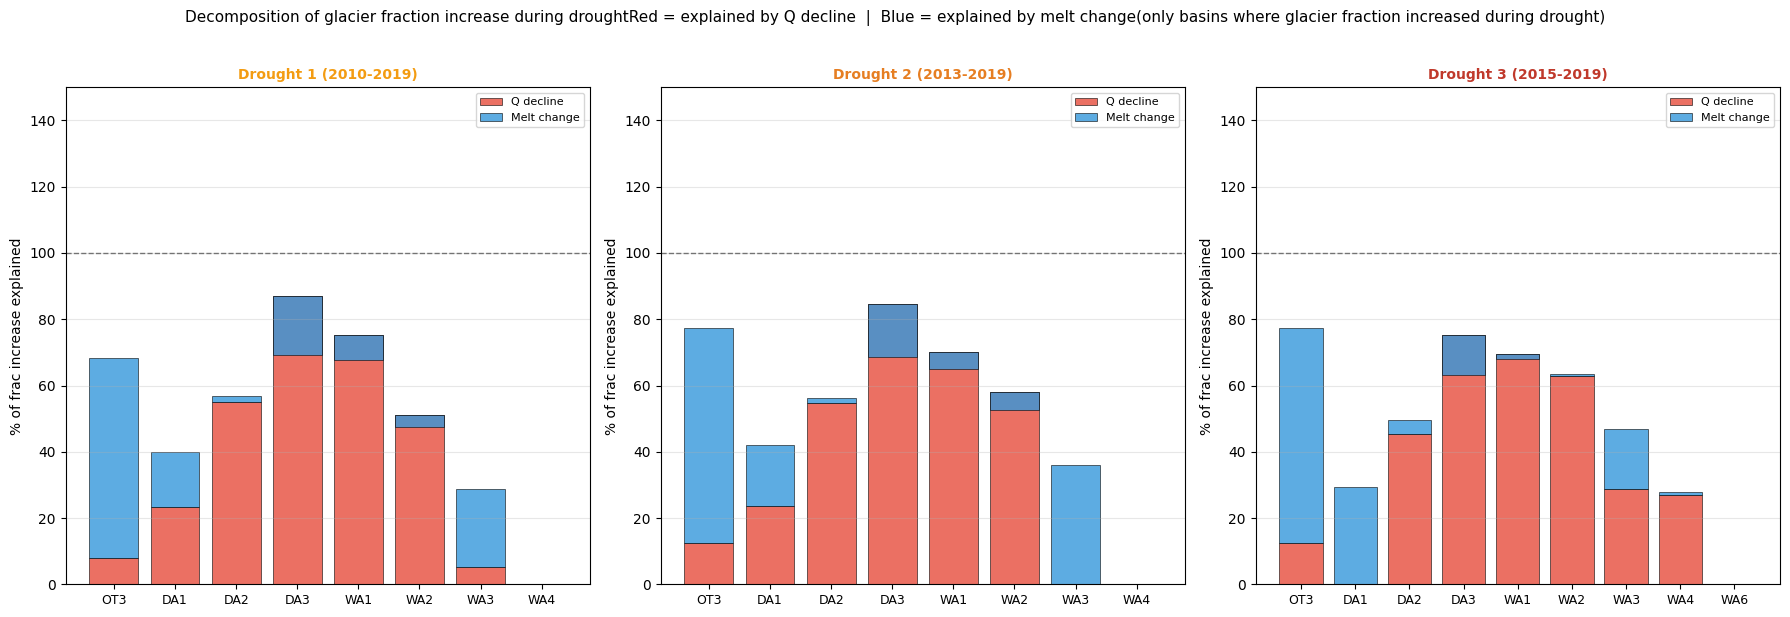

Median decomposition across all basins (amplifying basins only):
Period                     Q decline %   Melt change %
-------------------------------------------------------
Drought 1 (2010-2019)      +57.6%          -3.1%
Drought 2 (2013-2019)      +56.1%          -2.1%
Drought 3 (2015-2019)      +57.4%          -0.5%


In [10]:
# ── Decompose amplification into Q-decline vs melt-increase ──────────────
# Counterfactual approach:
# If frac = glac/Q, then the change in frac can be decomposed:
# Hold Q constant at baseline -> frac_cf_q = glac_drought / q_base
# Hold glac constant at baseline -> frac_cf_glac = glac_base / q_drought
# Actual frac_drought = glac_drought / q_drought

# % of amplification explained by Q decline:
# (frac_cf_q - frac_base) / (frac_drought - frac_base)

decomp_records = []
for gauge_id in GAUGE_INFO_FRAC:
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        base_row = df_periods[
            (df_periods['gauge_id'] == gauge_id) &
            (df_periods['dataset']  == ds_name) &
            (df_periods['period']   == 'Baseline (2000-2009)')
        ]
        if len(base_row) == 0:
            continue
        frac_base = base_row['frac_mean'].values[0]
        glac_base = base_row['glac_km3yr'].values[0]
        q_base    = base_row['q_km3yr'].values[0]

        for period_label in list(DROUGHT_DEFS.keys())[1:]:
            dr_row = df_periods[
                (df_periods['gauge_id'] == gauge_id) &
                (df_periods['dataset']  == ds_name) &
                (df_periods['period']   == period_label)
            ]
            if len(dr_row) == 0:
                continue
            frac_dr = dr_row['frac_mean'].values[0]
            glac_dr = dr_row['glac_km3yr'].values[0]
            q_dr    = dr_row['q_km3yr'].values[0]

            delta = frac_dr - frac_base
            if abs(delta) < 1e-10 or q_base == 0:
                continue

            # Counterfactual fractions
            frac_cf_q    = glac_dr   / q_base    # melt changes, Q fixed
            frac_cf_glac = glac_base / q_dr      # Q changes, melt fixed

            pct_q_decline   = (frac_cf_glac - frac_base) / delta * 100
            pct_melt_change = (frac_cf_q    - frac_base) / delta * 100

            decomp_records.append({
                'gauge_id':       gauge_id,
                'cluster':        GAUGE_INFO_FRAC[gauge_id]['clusters'][0],
                'lat':            GAUGE_INFO_FRAC[gauge_id]['cen_lat'],
                'dataset':        ds_name,
                'period':         period_label,
                'frac_base':      frac_base,
                'frac_drought':   frac_dr,
                'delta_frac':     delta,
                'pct_q_decline':  np.clip(pct_q_decline,   -200, 200),
                'pct_melt_chg':   np.clip(pct_melt_change, -200, 200),
            })

df_decomp = pd.DataFrame(decomp_records)

# ── Figure: stacked bar of Q-decline vs melt-change contribution ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, period_label in zip(axes, list(DROUGHT_DEFS.keys())[1:]):
    period_df = df_decomp[df_decomp['period'] == period_label]

    cl_q_med    = []
    cl_melt_med = []
    cl_labels   = []

    for cl in CLUSTERS:
        sub = period_df[
            (period_df['cluster'] == cl) &
            (period_df['delta_frac'] > 0)   # only amplifying basins
        ]
        if len(sub) < 3:
            continue
        cl_q_med.append(sub['pct_q_decline'].median())
        cl_melt_med.append(sub['pct_melt_chg'].median())
        cl_labels.append(cl)

    x = np.arange(len(cl_labels))
    ax.bar(x, cl_q_med,    label='Q decline',
           color='#e74c3c', alpha=0.8, edgecolor='k', lw=0.5)
    ax.bar(x, cl_melt_med, bottom=cl_q_med,
           label='Melt change', color='#3498db',
           alpha=0.8, edgecolor='k', lw=0.5)
    ax.axhline(100, color='k', lw=1, ls='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(cl_labels, fontsize=9)
    ax.set_ylabel('% of frac increase explained', fontsize=10)
    ax.set_title(period_label, fontsize=10, fontweight='bold',
                 color=DROUGHT_COLORS[period_label])
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 150)

fig.suptitle(
    'Decomposition of glacier fraction increase during drought'
    'Red = explained by Q decline  |  Blue = explained by melt change'
    '(only basins where glacier fraction increased during drought)',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/drought_amplification_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print('Median decomposition across all basins (amplifying basins only):')
print(f'{"Period":25s}  {"Q decline %":12s}  {"Melt change %"}')
print('-' * 55)
for period_label in list(DROUGHT_DEFS.keys())[1:]:
    sub = df_decomp[
        (df_decomp['period']     == period_label) &
        (df_decomp['delta_frac'] > 0)]
    print(f'{period_label:25s}  '
          f'{sub["pct_q_decline"].median():+.1f}%{"":8s}  '
          f'{sub["pct_melt_chg"].median():+.1f}%')


## VI. Climate driver analysis

What drove the drought? We compare temperature, precipitation, and PET
anomalies during each drought period vs baseline, to assess whether the
amplified glacier contribution reflects:
- Lower precipitation (less competing water)
- Higher temperatures (more melt + less snow)
- Higher PET (more evaporative demand reducing Q)
- Or some combination


Climate driver summary by cluster and period:



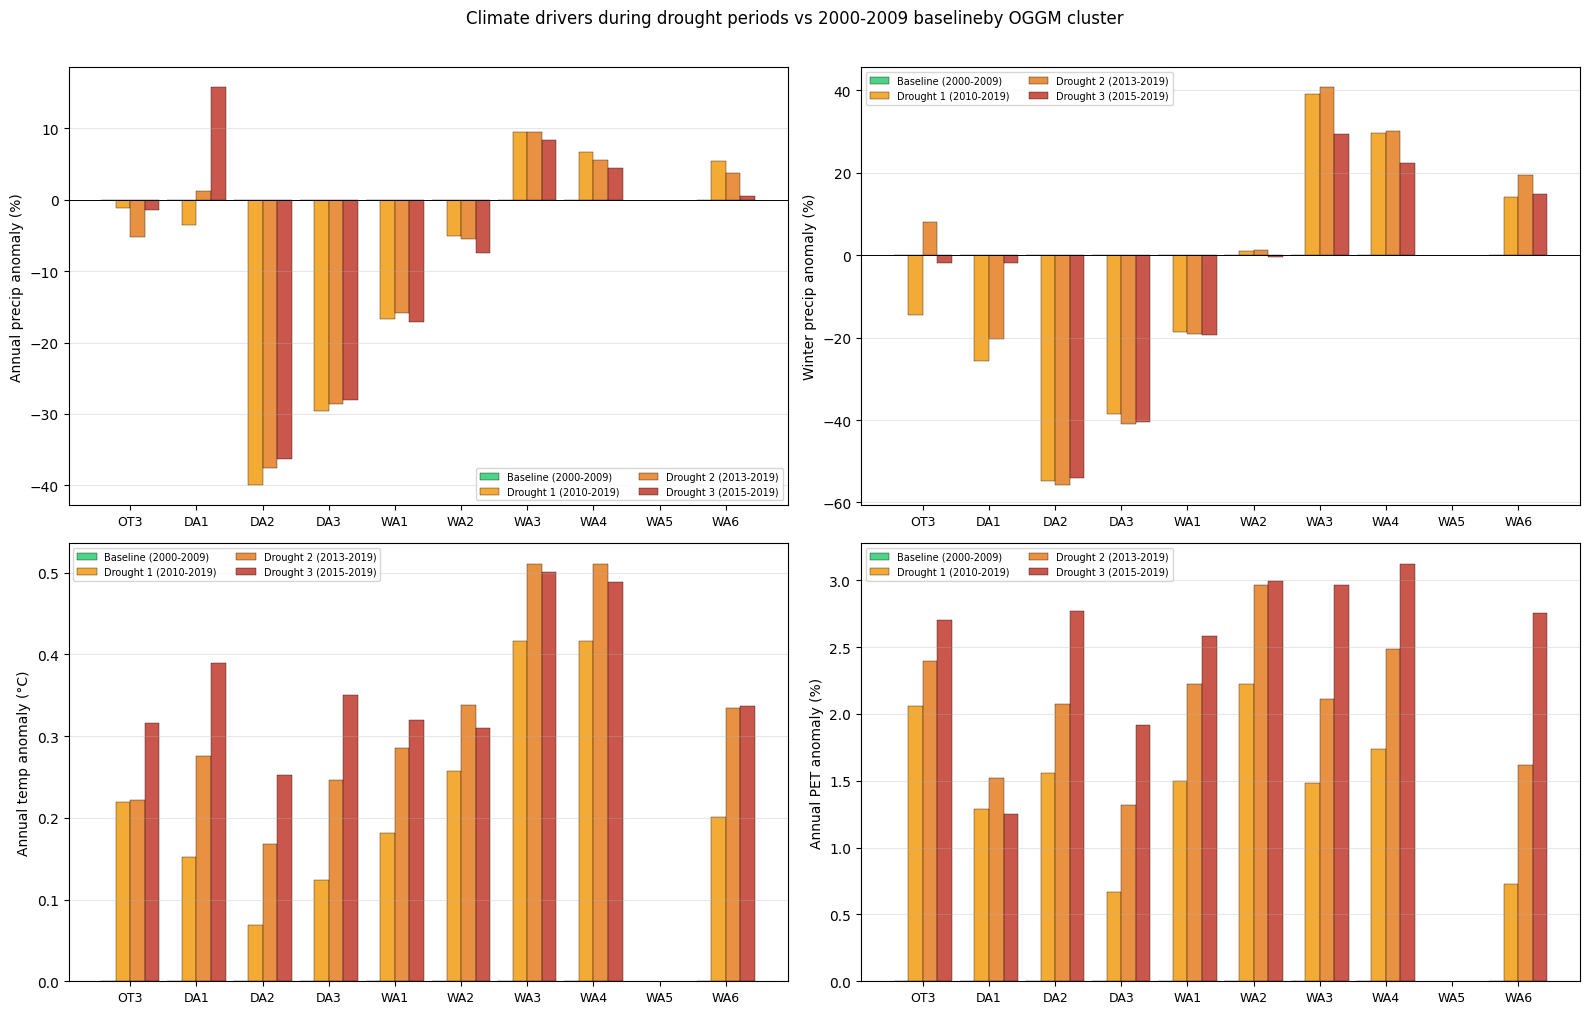

In [11]:
# ── PET and temperature anomalies during drought periods ─────────────────
print('Climate driver summary by cluster and period:')
print()

driver_records = []
for cl in CLUSTERS:
    cl_df = df_clim[df_clim['cluster'] == cl].set_index('year')
    for period_label, years in DROUGHT_DEFS.items():
        period_df = cl_df[cl_df.index.isin(years)]
        driver_records.append({
            'cluster':          cl,
            'period':           period_label,
            'precip_ann':       period_df['precip_ann'].mean(),
            'precip_ann_anom':  period_df['precip_ann_anom_pct'].mean(),
            'precip_win_anom':  period_df['precip_win_anom_pct'].mean(),
            'tmean_anom':       period_df['tmean_anom'].mean(),
            'pet_anom_pct':     period_df['pet_anom_pct'].mean(),
        })

df_drivers = pd.DataFrame(driver_records)

# ── Figure: 4-panel driver summary across clusters ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

driver_vars = [
    ('precip_ann_anom', 'Annual precip anomaly (%)',     True),
    ('precip_win_anom', 'Winter precip anomaly (%)',      True),
    ('tmean_anom',      'Annual temp anomaly (°C)',       False),
    ('pet_anom_pct',    'Annual PET anomaly (%)',         True),
]

x       = np.arange(len(CLUSTERS))
width   = 0.22
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

for ax, (var, ylabel, is_pct) in zip(axes.flatten(), driver_vars):
    for i, (period_label, years) in enumerate(list(DROUGHT_DEFS.items())):
        vals = []
        for cl in CLUSTERS:
            sub = df_drivers[
                (df_drivers['cluster'] == cl) &
                (df_drivers['period']  == period_label)]
            vals.append(sub[var].values[0] if len(sub) else np.nan)
        ax.bar(x + offsets[i], vals, width,
               label=period_label,
               color=DROUGHT_COLORS[period_label],
               alpha=0.85, edgecolor='k', lw=0.3)

    ax.axhline(0, color='k', lw=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(CLUSTERS, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=7, ncol=2)

fig.suptitle(
    'Climate drivers during drought periods vs 2000-2009 baseline'
    'by OGGM cluster',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DROUGHT_DIR}/climate_drivers_by_period_cluster.png',
            dpi=150, bbox_inches='tight')
plt.show()


## VII. Chile map — drought amplification factor

Map of glacier fraction amplification factor (drought / baseline) for all
137 gauged basins, for each of the three drought period definitions.
Shows where across Chile the relative importance of glacier melt increased
most strongly during drought.


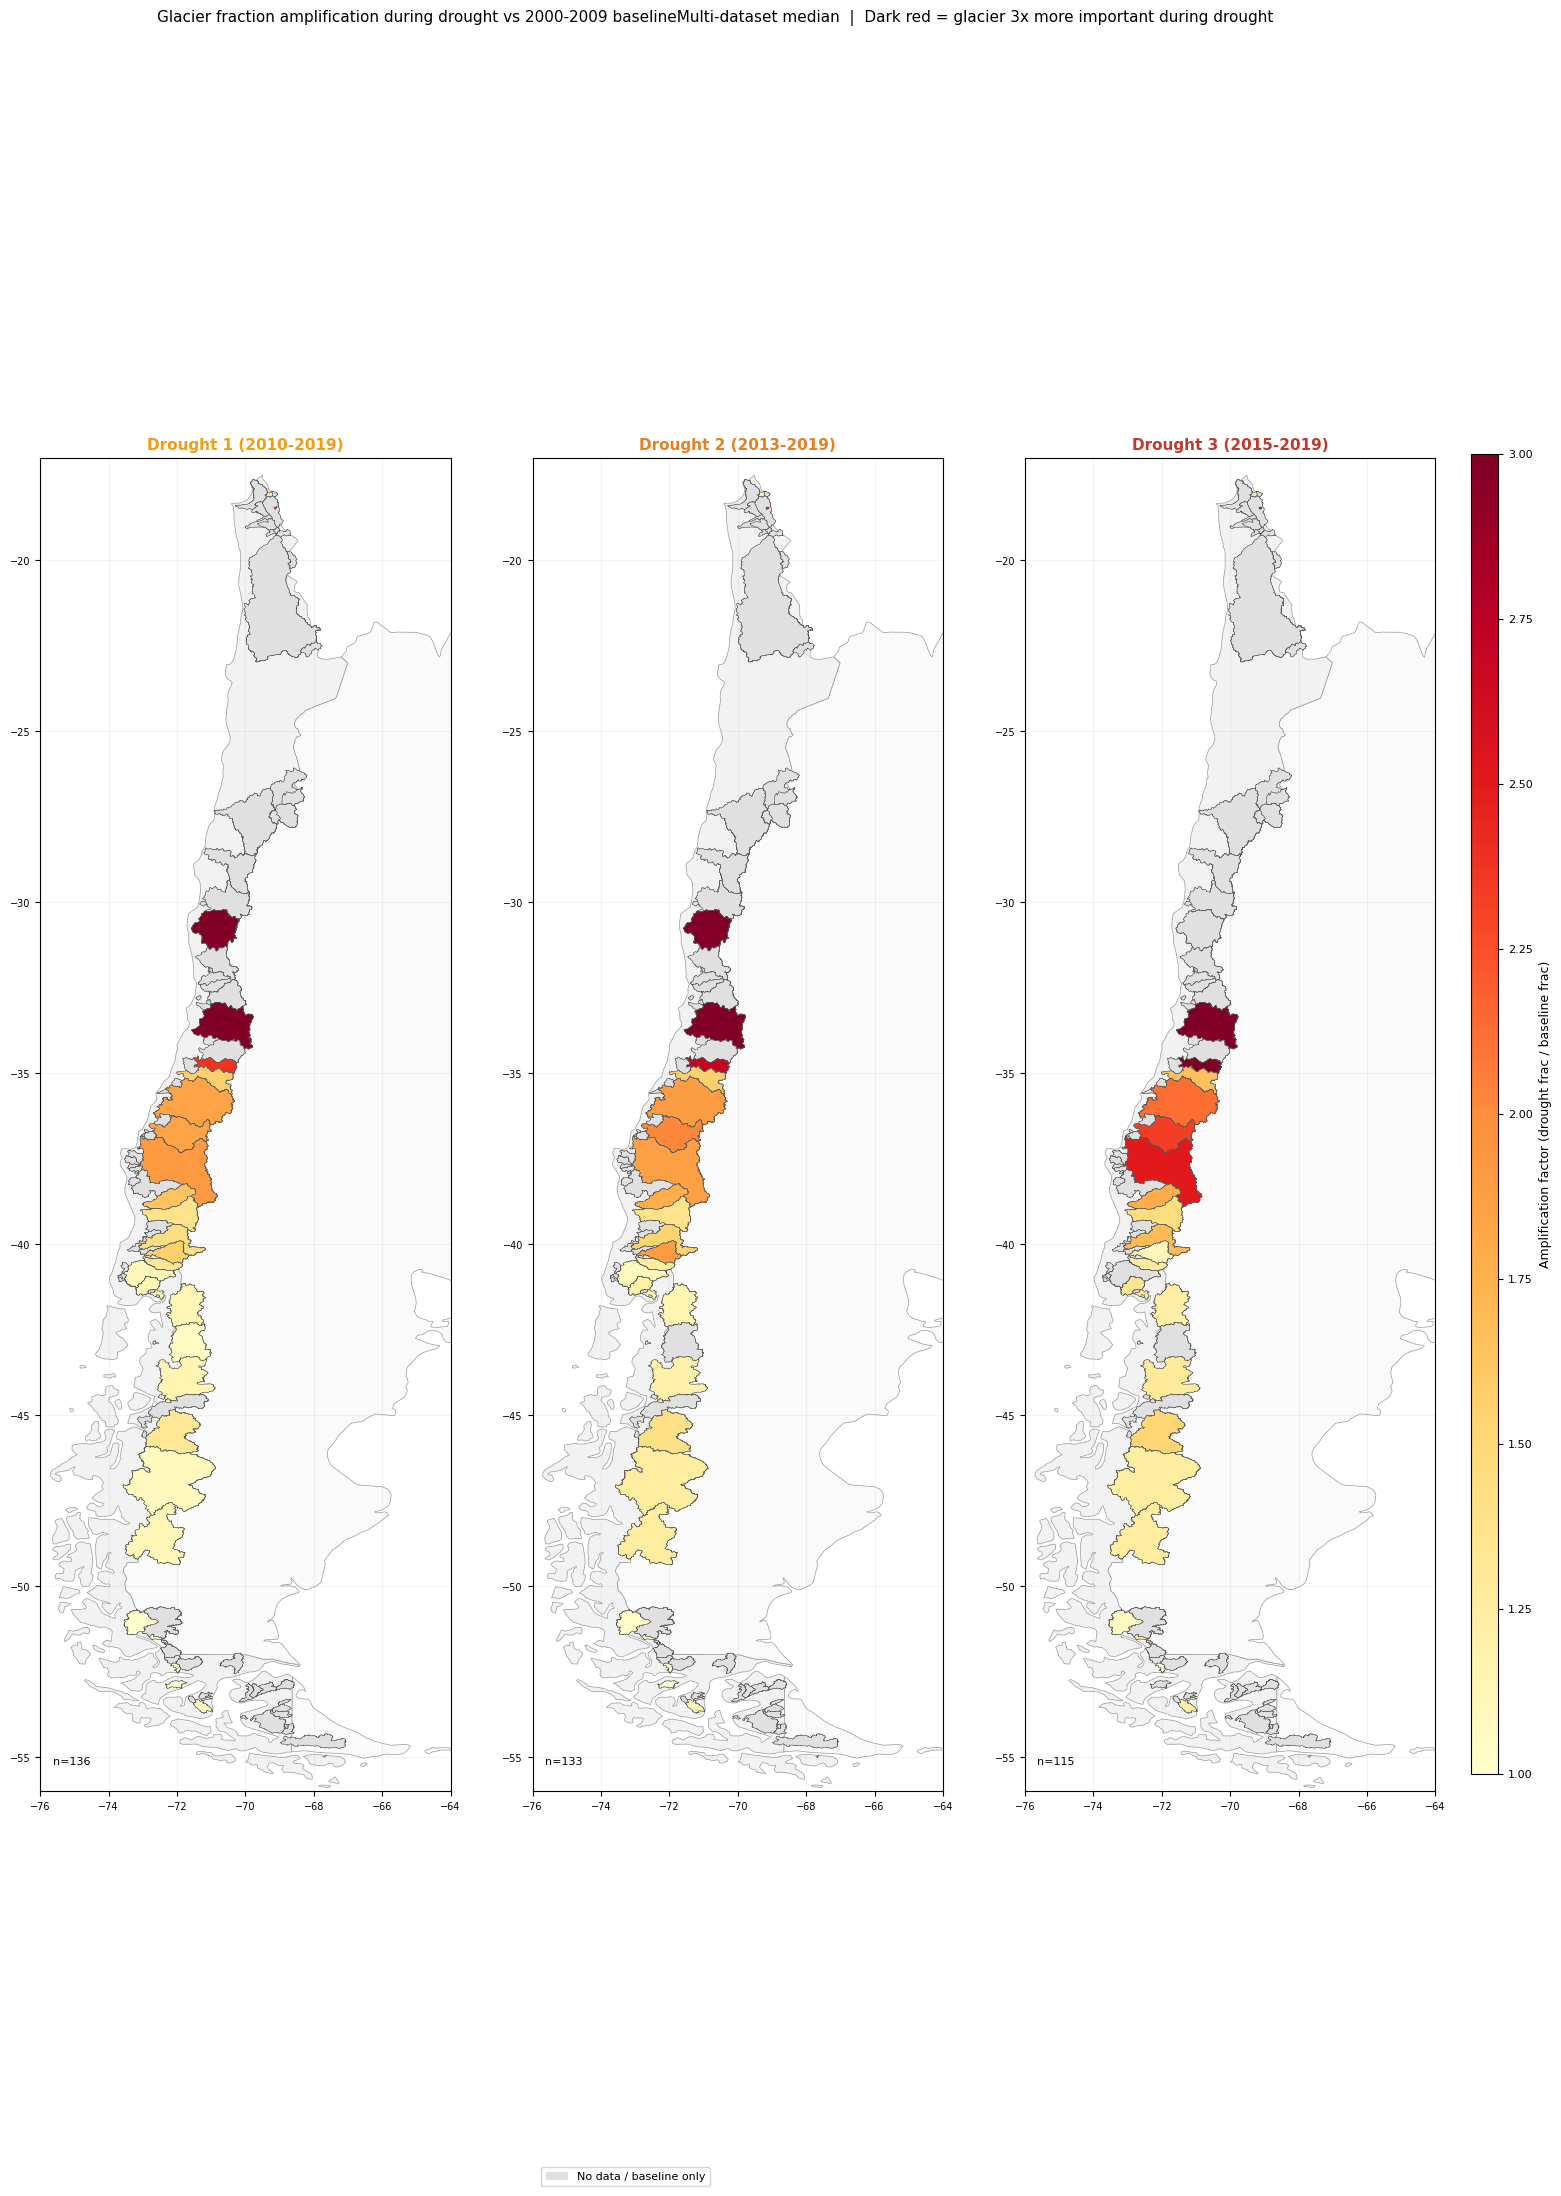

In [13]:
# ── Load spatial data ─────────────────────────────────────────────────────
bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)

try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/'
        'ne_50m_admin_0_countries.zip')
    chile       = world[world['NAME'] == 'Chile']
    arg         = world[world['NAME'] == 'Argentina']
    has_borders = True
except Exception:
    has_borders = False
    print('Country borders unavailable')

# Multi-dataset mean amplification factor per basin per period
amp_mean = (df_periods[df_periods['amp_factor'].between(0, 10)]
            .groupby(['gauge_id','period'])['amp_factor']
            .median().reset_index()
            .rename(columns={'amp_factor': 'amp_med'}))

# ── Plot ──────────────────────────────────────────────────────────────────
drought_periods = list(DROUGHT_DEFS.keys())[1:]
fig, axes = plt.subplots(1, 3, figsize=(18, 22))

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

cmap_amp = plt.cm.YlOrRd
norm_amp = Normalize(vmin=1.0, vmax=3.0)

for ax, period_label in zip(axes, drought_periods):
    if has_borders:
        chile.plot(ax=ax, facecolor='#f2f2f2',
                   edgecolor='#999999', linewidth=0.5, zorder=0)
        arg.plot(ax=ax,   facecolor='#fafafa',
                 edgecolor='#999999', linewidth=0.5, zorder=0)

    # Background grey
    bounds.plot(ax=ax, facecolor='#e0e0e0', edgecolor='#cccccc',
                linewidth=0.2, zorder=1)

    # Merge amp factor
    period_amp = amp_mean[amp_mean['period'] == period_label]
    bounds_plot = bounds.merge(
        period_amp[['gauge_id','amp_med']],
        on='gauge_id', how='left')

    from matplotlib.colors import to_hex
    face_colors = [
        to_hex(cmap_amp(norm_amp(v))) if not np.isnan(v) else '#e0e0e0'
        for v in bounds_plot['amp_med'].values]
    bounds_plot.plot(ax=ax, color=face_colors,
                     edgecolor='#555555', linewidth=0.3, zorder=2)

    ax.set_xlim(-76, -64)
    ax.set_ylim(-56, -17)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15)
    ax.set_title(period_label, fontsize=11, fontweight='bold',
                 color=DROUGHT_COLORS[period_label])

    n_valid = period_amp['amp_med'].notna().sum()
    ax.text(0.03, 0.02, f'n={n_valid}',
            transform=ax.transAxes, fontsize=8)

# Shared colorbar
sm = ScalarMappable(cmap=cmap_amp, norm=norm_amp)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Amplification factor (drought frac / baseline frac)',
             fontsize=9)
cb.ax.tick_params(labelsize=8)

fig.legend(
    handles=[
        plt.Rectangle((0,0),1,1, facecolor='#e0e0e0',
                       label='No data / baseline only')],
    loc='lower center', fontsize=8,
    bbox_to_anchor=(0.45, 0.01))

fig.suptitle(
    'Glacier fraction amplification during drought vs 2000-2009 baseline'
    'Multi-dataset median  |  Dark red = glacier 3x more important during drought',
    fontsize=11, y=1.002)
plt.savefig(f'{DROUGHT_DIR}/drought_amplification_map.png',
            dpi=150, bbox_inches='tight')
plt.show()


## VIII. Summary of findings

### What we found

**1. Empirical validation of drought period definitions**

The megadrought was not a Chile-wide phenomenon. Precipitation deficits were
concentrated in central and northern Chile:

- DA2 (Dry Andes Central): -37 to -40% annual precipitation across all three
  periods — the most severely and consistently affected cluster
- DA3 (Dry Andes South): -28 to -30%
- WA1 (Araucanía): -16 to -17%

Patagonia (WA3, WA4, WA6) actually received above-normal precipitation during
the same periods (+5 to +39%), meaning the Chilean Megadrought as defined here
is a central Chile phenomenon, consistent with Garreaud et al. (2020).

The three drought period definitions (2010-2019, 2013-2019, 2015-2019) do not
represent uniformly progressive severity — the pattern depends strongly on
cluster. DA2 shows consistent severity across all three periods. DA1 shows
declining severity in 2015-2019 as conditions shifted from dry to warm drought.
WA1 shows slightly increasing severity in the most recent period.

**2. Snow drought classification**

Two distinct drought mechanisms operated across Chile's latitudinal gradient:

- **Dry snow drought** (DA1, DA2, DA3, WA1): large winter precipitation deficits
  (-19 to -55%) with modest warming. In high snow-fraction clusters (DA1: 0.53,
  DA2: 0.69), this directly reduced snowpack. In WA1 (snow fraction: 0.035),
  the winter deficit was primarily a rainfall deficit since almost no
  precipitation falls as snow at gauge elevations.

- **Warm snow drought** (WA2, WA3, WA4, WA6): winter precipitation was near-
  normal or above-normal, but temperatures increased by +0.3 to +0.5°C.
  Patagonia received 14-41% more winter precipitation than baseline while
  warming, potentially shifting precipitation from snow to rain at elevation
  and reducing snowpack despite higher total precipitation. This is a genuine
  warm snow drought signal, though the absolute snowpack impact is limited
  given the low climatological snow fractions in these clusters (0.10-0.11).

DA3 and WA1 transitioned from dry snow drought (2010-2019) to compound drought
(dry + warm) by 2015-2019 as temperature anomalies crossed the +0.3°C threshold.

**3. Glacier fraction amplification**

Glacier runoff fractions amplified substantially in drought-affected clusters:

- DA2: 2.8-3.7x the baseline fraction — the strongest amplification signal
- DA1: 1.5-2.7x (stronger in earlier periods, weaker in 2015-2019 when the
  drought mechanism shifted from dry to warm)
- DA3: 1.9-2.1x
- WA1: 1.6-1.8x, strengthening progressively across the three periods
- WA2: 1.2-1.4x
- WA3, WA4: 1.0-1.2x — minimal amplification consistent with no precipitation
  deficit in Patagonia
- WA6: 0.80-1.23x — glacier contributions actually declined during the earlier
  drought periods when Patagonian Q increased

**4. Decomposition: Q decline vs melt change**

Across all amplifying basins (pooled, all three periods), Q decline accounts
for approximately 57% of the glacier fraction increase while melt change
accounts for approximately -3 to -0.5% — meaning melt slightly declined on
average across amplifying basins, and the amplification signal is driven
almost entirely by streamflow reduction.

However this pooled result masks an important north-south contrast:

- **Active amplification (OT3, DA1, DA2)**: glacier melt increased
  substantially (+17 to +57%) during drought, likely due to warmer temperatures
  and reduced snow cover exposing bare ice. Both Q decline and melt increase
  contributed to higher glacier fractions.

- **Passive buffering (DA3, WA1, WA2, WA3, WA4)**: glacier melt changed far
  less during drought (within -9% to +5%). The amplified glacier fraction is
  driven primarily by streamflow decline while glacier melt remained relatively
  stable — glaciers buffered drought passively rather than producing more water.

- **De-amplification (WA6)**: glacier melt declined (-13%) while Q increased,
  resulting in reduced glacier fractions during the megadrought period.

**5. Climate drivers**

Temperature anomalies during drought were modest (+0.07 to +0.42°C depending
on cluster and period) compared to precipitation deficits (-55% in DA2).
Precipitation decline is the dominant driver of drought amplification in
central Chile. Temperature plays a secondary role but becomes more important
in the most recent period (2015-2019) and in Patagonia where precipitation
was above normal.

---

### Pending analyses flagged for next session

- **Temporal trend analysis**: is glacier fraction increasing over 2000-2019
  independent of drought (i.e. a secular trend separate from megadrought
  amplification)? Flagged as a priority contribution.

- **Peak water analysis**: which basins have already passed peak water and
  what is the projected magnitude of future streamflow decline?

- **Extend to February and DJF**: the annual analysis likely underestimates
  peak drought amplification. February fractions should be substantially
  higher than annual means. Extend Cell IV to seasonal and monthly resolution.

- **Deseasonalize WA1 lag**: verify whether the 5.5-month median lag in WA1
  reflects genuine volcanic aquifer routing or seasonal aliasing.

- **Integrate snow fraction into drought classification**: weight winter
  precipitation anomalies by climatological snow fraction per basin to
  produce a physically meaningful snow water equivalent deficit estimate,
  rather than treating all winter precipitation changes equivalently.

- **Connect megadrought findings to regression results**: the basins where
  glacier signals are statistically significant (per-basin MLR) should
  overlap with the basins showing the highest drought amplification factors.
  Test this explicitly.